In [2]:
import numpy as np
import matplotlib.pyplot as plt

## "Un passo nel MAGGICO mondo della stocasticità"

#### Modello di Ricker o Logistico con parametro r e condizioni iniziali stocastiche

In [27]:
def RickerMap(r, k, x):
    return x*np.exp(r*(1-x/k))

def LogisticMap(r, k, x):
    return x + r*x*(1-x/k)

def ComputeMultiTrajectories(r_mean, r_std, k, iterations, n_trajectories, x0_mean, x0_std, discrete_map):
    y = np.zeros((n_trajectories,iterations))
    
    for i in range(n_trajectories):
        y[i, 0] = abs(np.random.normal(x0_mean, x0_std, 1))

    for i in range(1, iterations):
        for j in range(n_trajectories):
            r = np.random.normal(r_mean, r_std, 1)
            y[j, i] = discrete_map(r, k, y[j, i-1])
    return y


C:\Users\Lorenzo\AppData\Local\Temp\ipykernel_888\845958637.py:11: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  y[i, 0] = abs(np.random.normal(x0_mean, x0_std, 1))
C:\Users\Lorenzo\AppData\Local\Temp\ipykernel_888\845958637.py:16: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  y[j, i] = discrete_map(r, k, y[j, i-1])


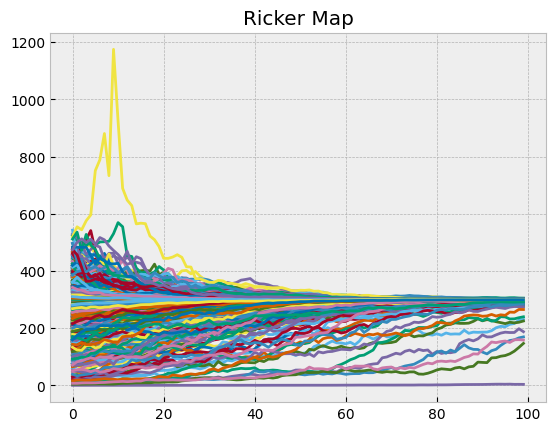

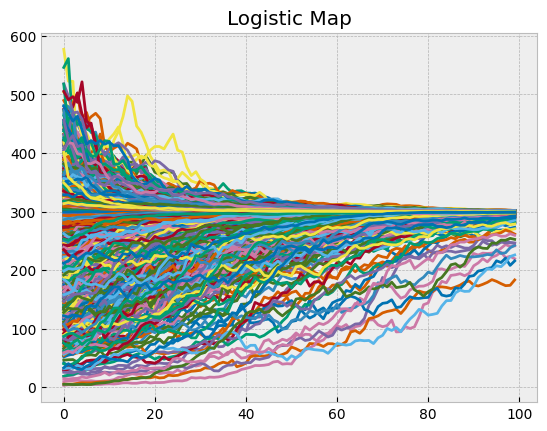

In [105]:
x0_mean = 250
x0_std = 100

r_mean = 0.05
r_std = 0.1

k = 300
iterations = 100

n_trajectories = 1000

y = ComputeMultiTrajectories(r_mean, r_std, k, iterations, n_trajectories, x0_mean, x0_std, RickerMap)
y2 = ComputeMultiTrajectories(r_mean, r_std, k, iterations, n_trajectories, x0_mean, x0_std, LogisticMap)

plt.figure()
plt.title('Ricker Map')
plt.plot(y.T)

plt.figure()
plt.title('Logistic Map')
plt.plot(y2.T)

Text(0.5, 1.0, 'Last point xt')

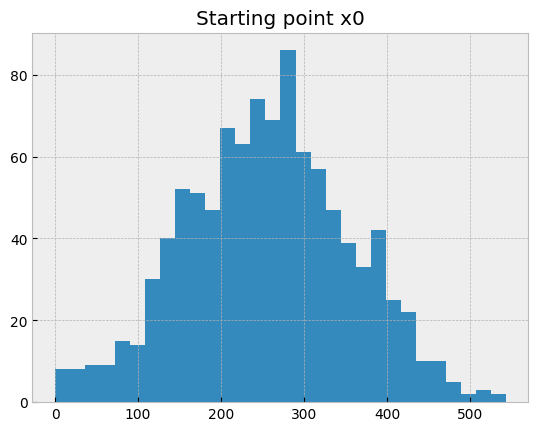

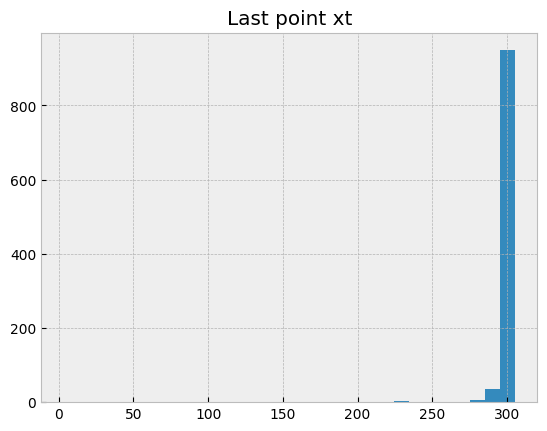

In [106]:
# two different plots: one for the starting point x0 and one for the last point xt

plt.figure()
plt.hist(y[:,0], bins=30)
plt.title('Starting point x0')

plt.figure()
plt.hist(y[:,-1], bins=30)
plt.title('Last point xt')




(array([9.03046571e-05, 0.00000000e+00, 0.00000000e+00, 1.80609314e-04,
        2.70913971e-04, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 1.80609314e-04, 9.03046571e-05, 0.00000000e+00,
        1.80609314e-04, 1.80609314e-04, 0.00000000e+00, 1.80609314e-04,
        1.80609314e-04, 1.80609314e-04, 9.03046571e-05, 3.61218628e-04,
        4.51523285e-04, 5.41827943e-04, 2.07700711e-03, 2.88974903e-03,
        5.23767011e-03, 9.66259831e-03, 3.25999812e-02, 3.27805905e-02,
        1.62548383e-03, 2.70913971e-04]),
 array([  0.38863993,  11.46226594,  22.53589195,  33.60951797,
         44.68314398,  55.75677   ,  66.83039601,  77.90402203,
         88.97764804, 100.05127405, 111.12490007, 122.19852608,
        133.2721521 , 144.34577811, 155.41940412, 166.49303014,
        177.56665615, 188.64028217, 199.71390818, 210.7875342 ,
        221.86116021, 232.93478622, 244.00841224, 255.08203825,
        266.15566427, 277.22929028, 288.3029163 , 299.37654231,
      

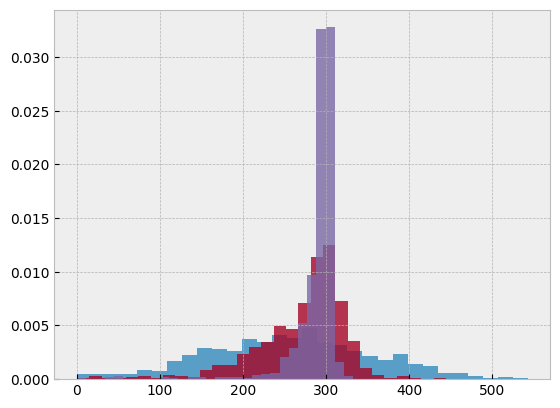

In [107]:
plt.style.use('bmh')

def plot_beta_hist(ax, a, b):
    ax.hist(np.random.beta(a, b, size=10000),
            histtype="stepfilled", bins=25, alpha=0.8, density=True)

plt.hist(y[:,0], bins=30, histtype="stepfilled", alpha=0.8, density=True)
plt.hist(y[:, 20], bins=30, histtype="stepfilled", alpha=0.8, density=True)
plt.hist(y[:, 50], bins=30, histtype="stepfilled", alpha=0.8, density=True)